# Toy studies
## Load and plot results from toy fits

### Turn off statistics box

In [1]:
gStyle->SetOptStat(false);

### Add BESIII style

In [2]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [3]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [4]:
SetStyle();
SetPrelimStyle();

### Parameters we want to look at

In [5]:
std::vector<std::string> Parameters{"c1", "c2", "c3", "c4",
                                    "s1", "s2", "s3", "s4",
                                    "R_M4", "R_M3", "R_M2", "R_M1",
                                    "R_P1", "R_P2", "R_P3",
                                    "BF_KKpipi", "BF_KKpipi_KLpipi",
                                    "rDcosDeltaKpi", "rDsinDeltaKpi"
};

### Parameters that are interesting

In [6]:
std::vector<std::string> InterestingParameters{"c1", "c2", "c3", "c4",
                                               "s1", "s2", "s3", "s4",
                                               "R_M4", "R_M3", "R_M2", "R_M1",
                                               "R_P1", "R_P2", "R_P3",
                                               "BF_KKpipi", "BF_KKpipi_KLpipi",
};

### Parameter names in plots

In [7]:
std::map<std::string, std::string> ParameterNames{
    {"c1", "c_{1}"},
    {"c2", "c_{2}"},
    {"c3", "c_{3}"},
    {"c4", "c_{4}"},
    {"s1", "s_{1}"},
    {"s2", "s_{2}"},
    {"s3", "s_{3}"},
    {"s4", "s_{4}"}
};

### Function to convert $K_i$ to $R_i$

In [8]:
std::vector<double> ConvertKiToRi(const std::vector<double> &Ki,
                                  const std::vector<double> &Kbari) {
    std::vector<double> MergedKi;
    const std::size_t N = Ki.size();
    for(std::size_t i = 0; i < N; i++) {
        MergedKi.push_back(Kbari[N - i - 1]);
    }
    for(std::size_t i = 0; i < N; i++) {
        MergedKi.push_back(Ki[i]);
    }
    std::vector<double> Ri;
    for(std::size_t i = 0; i < 2*N; i++) {
        Ri.push_back(MergedKi[i]);
        if(i != 0) {
            double Sum = 0;
            for(std::size_t j = i; j < 2*N; j++) {
                Sum += MergedKi[j];
            }
            Ri[i] /= Sum;
        }
    }
    return Ri;
}

### Load generator values

In [9]:
std::map<std::string, double> GetGeneratorValues() {
    std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb/cisiFit/cisi_Settings.txt";
    std::ifstream File(Filename);
    std::string Line;
    std::map<std::string, double> GeneratorValues;
    while(std::getline(File, Line)) {
        if(Line.empty()) {
            continue;
        }
        std::string Name;
        double Value;
        std::stringstream ss(Line);
        ss >> Name >> Value;
        if(Name.substr(0, 10) == "Generator_") {
            GeneratorValues.insert({Name.substr(10, Name.length()), Value});
        }
    }
    File.close();
    GeneratorValues.insert({"BF_KKpipi_KLpipi", GeneratorValues.at("BF_KKpipi")});
    /*std::vector<double> Ki, Kbari;
    for(std::size_t Bin = 1; Bin <= 4; Bin++) {
        Ki.push_back(GeneratorValues.at("K" + std::to_string(Bin)));
        Kbari.push_back(GeneratorValues.at("Kbar" + std::to_string(Bin)));
    }
    const auto Ri = ConvertKiToRi(Ki, Kbari);
    int Bin = -4;
    std::size_t Counter = 0;
    while(Bin < 4) {
        if(Bin == 0) {
            Bin++;
            continue;
        }
        std::string Name("R_");
        Name += (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        GeneratorValues.insert({Name, Ri[Counter]});
        Bin++;
        Counter++;
    }*/
    return GeneratorValues;
}

In [10]:
auto GeneratorValues = GetGeneratorValues();

### Pull histograms

In [11]:
std::map<std::string, TH1D> Histograms_pull, Histograms_value,
                            Histograms_plus_err, Histograms_minus_err, Histograms_err;
for(const auto &Parameter : Parameters) {
    Histograms_pull.insert({Parameter, TH1D((Parameter + "_pull_h").c_str(), "", 100, -4.0, 4.0)});
    if(Parameter[0] == 's' || Parameter[0] == 'c') {
        Histograms_pull[Parameter].SetLineWidth(3);
        Histograms_pull[Parameter].SetLineColor(kBlack);
        Histograms_pull[Parameter].SetMarkerStyle(8);
        Histograms_pull[Parameter].SetTitle((";(" + ParameterNames[Parameter] + "^{fit}-"
                                             + ParameterNames[Parameter] + "^{gen})/#sigma("
                                             + ParameterNames[Parameter] + "); Entries").c_str());
    }
    Histograms_plus_err.insert({Parameter, TH1D((Parameter + "_plus_err_h").c_str(), "", 50, 0.0, 0.0)});
    Histograms_minus_err.insert({Parameter, TH1D((Parameter + "_minus_err_h").c_str(), "", 50, 0.0, 0.0)});
    Histograms_err.insert({Parameter, TH1D((Parameter + "_err_h").c_str(), "", 50, 0.0, 0.0)});
    Histograms_value.insert({Parameter, TH1D((Parameter + "_value_h").c_str(), "", 50, 0.0, 0.0)});
}

### File with toy values for bias corrections later

In [12]:
std::ofstream ToyBiasFile("ToyValuesForBiasCorrections.txt");

### Name of directory containing toys

In [13]:
const std::string ToyDir = "ToyFitResults/";

### Tree where pull results are dumped

In [14]:
TTree PullTree("PullTree", "PullTree");
std::map<std::string, double> TreeVariables;
TreeVariables.insert({"LL", 0.0});
PullTree.Branch("LL", &TreeVariables["LL"]);
for(const auto &Parameter : Parameters) {
    TreeVariables.insert({Parameter + "_value", 0.0});
    TreeVariables.insert({Parameter + "_err", 0.0});
    TreeVariables.insert({Parameter + "_pull", 0.0});
    PullTree.Branch((Parameter + "_value").c_str(), &TreeVariables[Parameter + "_value"]);
    PullTree.Branch((Parameter + "_err").c_str(), &TreeVariables[Parameter + "_err"]);
    PullTree.Branch((Parameter + "_pull").c_str(), &TreeVariables[Parameter + "_pull"]);
}

### Function that loads toys and calculates pulls

In [15]:
void LoadToy(std::size_t ToyNumber) {
    // Filename
    std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb/cisiFit/" + ToyDir;
    //std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_20fb_No2024/cisiFit/" + ToyDir;
    Filename += "Toy" + std::to_string(ToyNumber) + ".root";
    // Load file
    TFile File(Filename.c_str(), "READ");
    if(File.IsZombie()) {
        return;
    }
    // Check if fit converged properly
    TParameter<int> *Status = nullptr, *CovStatus = nullptr;
    File.GetObject("Status", Status);
    File.GetObject("CovStatus", CovStatus);
    if(Status->GetVal() != 0 || CovStatus->GetVal() != 3) {
        return;
    }
    TParameter<double> *LL = nullptr;
    File.GetObject("LL", LL);
    TreeVariables["LL"] = LL->GetVal();
    std::vector<std::string> *VariableNames = nullptr;
    File.GetObject("VariableNames", VariableNames);
    std::vector<double> *FitValues = nullptr;
    File.GetObject("FitValues", FitValues);
    /*std::vector<double> *PlusUncertainties = nullptr;
    File.GetObject("PlusUncertainties", PlusUncertainties);
    std::vector<double> *MinusUncertainties = nullptr;
    File.GetObject("MinusUncertainties", MinusUncertainties);*/
    std::vector<double> *FitUncertainties = nullptr;
    File.GetObject("FitUncertainties", FitUncertainties);
    for(const auto &Parameter : Parameters) {
        std::size_t i = std::find(VariableNames->begin(),
                                  VariableNames->end(),
                                  Parameter) - VariableNames->begin();
        /*if((*PlusUncertainties)[i] > 1.0 || (*MinusUncertainties)[i] < -1.0) {
            continue;
        }
        if(Parameter[0] == 's' && ((*PlusUncertainties)[i] < 0.1 || (*MinusUncertainties)[i] > -0.1)) {
            continue;
        }*/
        double Pull = (*FitValues)[i] - GeneratorValues[Parameter];
        //Pull /= (Pull <= 0.0 ? (*PlusUncertainties)[i] : -(*MinusUncertainties)[i]);
        Pull /= (*FitUncertainties)[i];
        Histograms_pull[Parameter].Fill(Pull);
        //Histograms_plus_err[Parameter].Fill((*PlusUncertainties)[i]);
        //Histograms_minus_err[Parameter].Fill(-(*MinusUncertainties)[i]);
        Histograms_err[Parameter].Fill((*FitUncertainties)[i]);
        Histograms_value[Parameter].Fill((*FitValues)[i]);
        TreeVariables[Parameter + "_value"] = (*FitValues)[i];
        TreeVariables[Parameter + "_err"] = (*FitUncertainties)[i];
        TreeVariables[Parameter + "_pull"] = Pull;
    }
    PullTree.Fill();
    for(const auto &Parameter : InterestingParameters) {
        std::size_t i = std::find(VariableNames->begin(),
                                  VariableNames->end(),
                                  Parameter) - VariableNames->begin();
        double Pull = (*FitValues)[i] - GeneratorValues[Parameter];
        if(Parameter[0] != 's') {
            Pull /= (*FitUncertainties)[i];
        }
        ToyBiasFile << Pull;
        if(Parameter != InterestingParameters.back()) {
            ToyBiasFile << " ";
        } else {
            ToyBiasFile << "\n";
        }
    }
}

### Load toys

In [16]:
for(std::size_t i = 0; i < 1000; i++) {
    LoadToy(i);
}

In [17]:
ToyBiasFile.close();
TFile PullFile("PullTree.root", "RECREATE");
PullTree.SetDirectory(&PullFile);
PullTree.Write();
PullFile.Close();

### Plot pulls

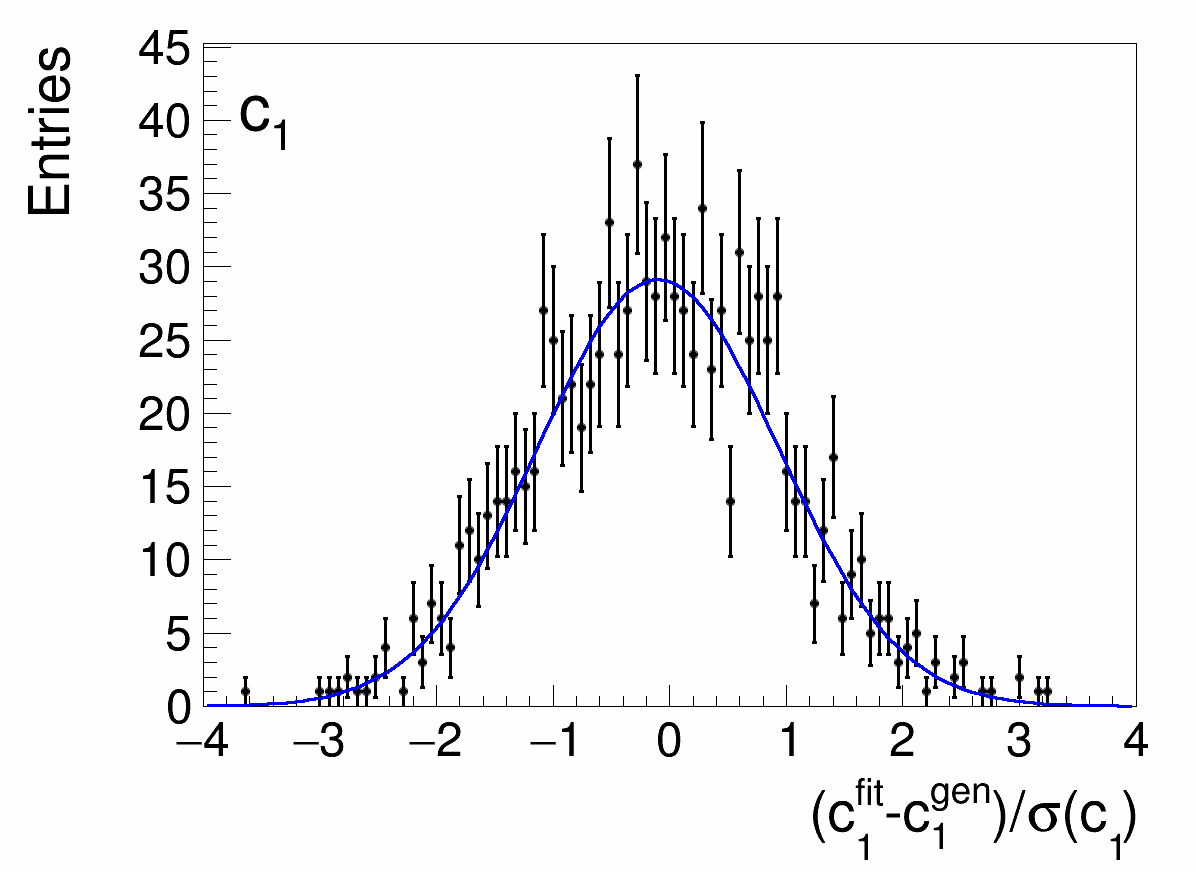

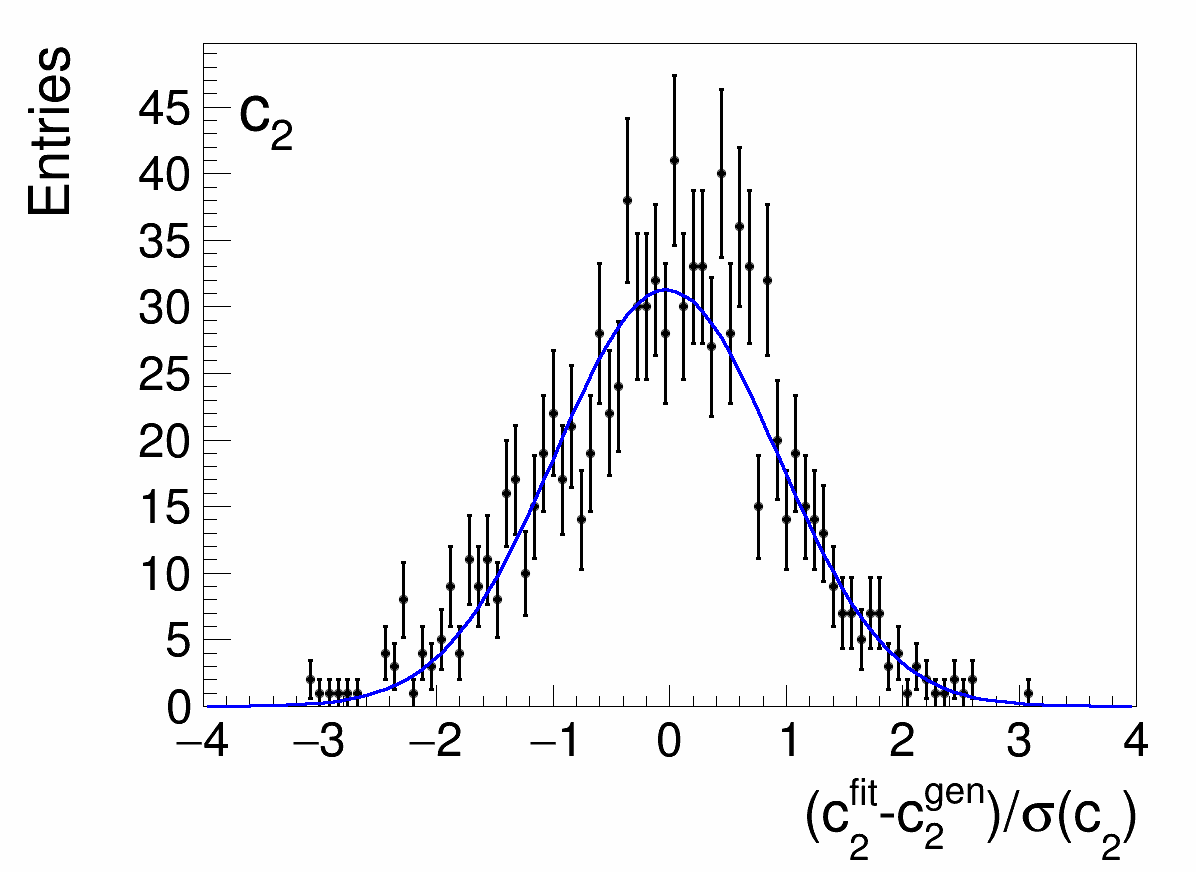

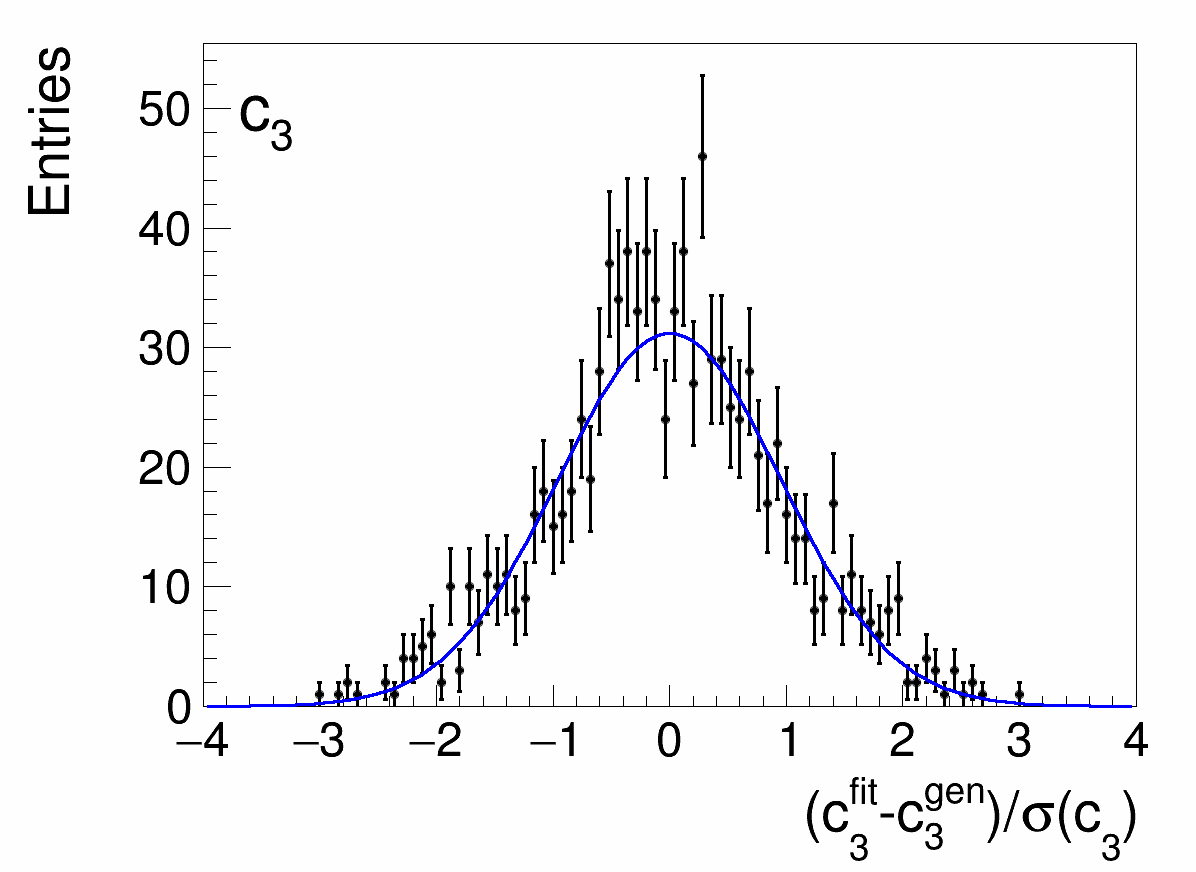

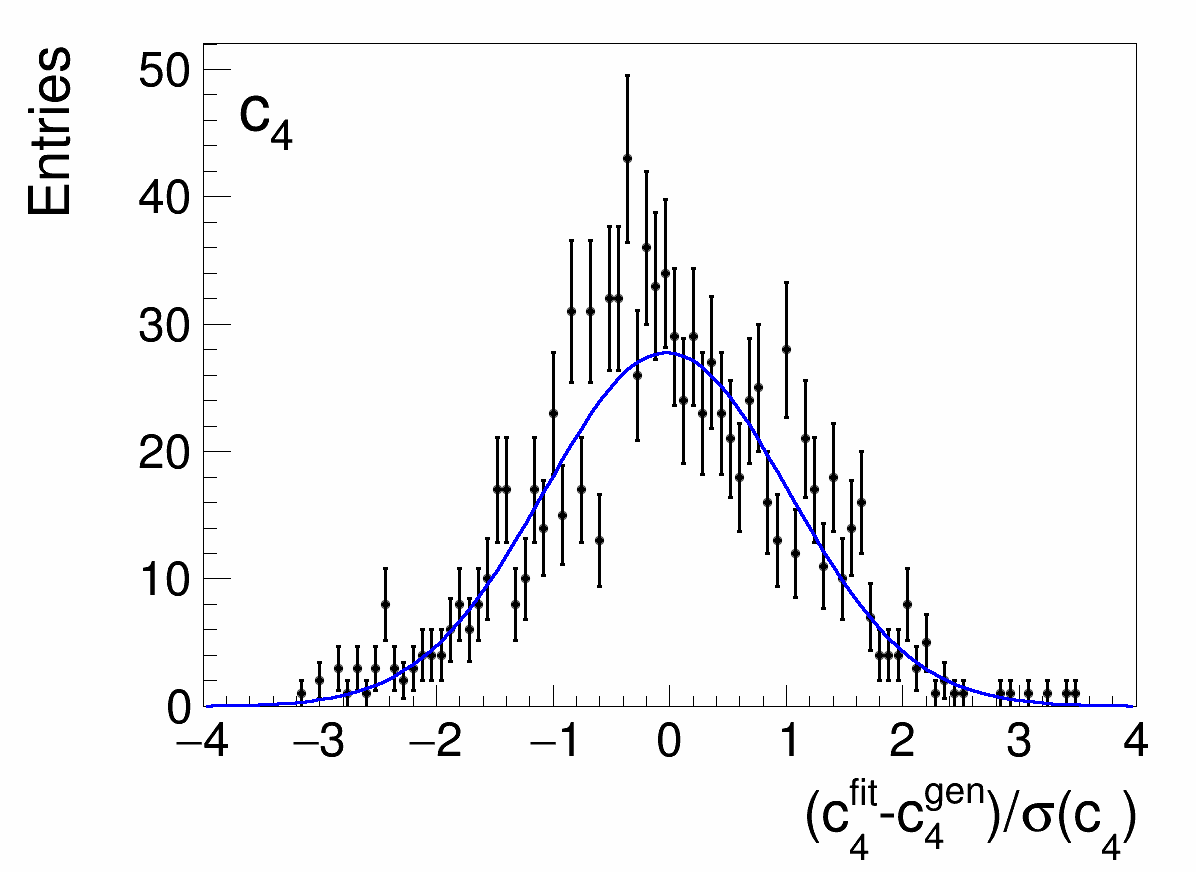

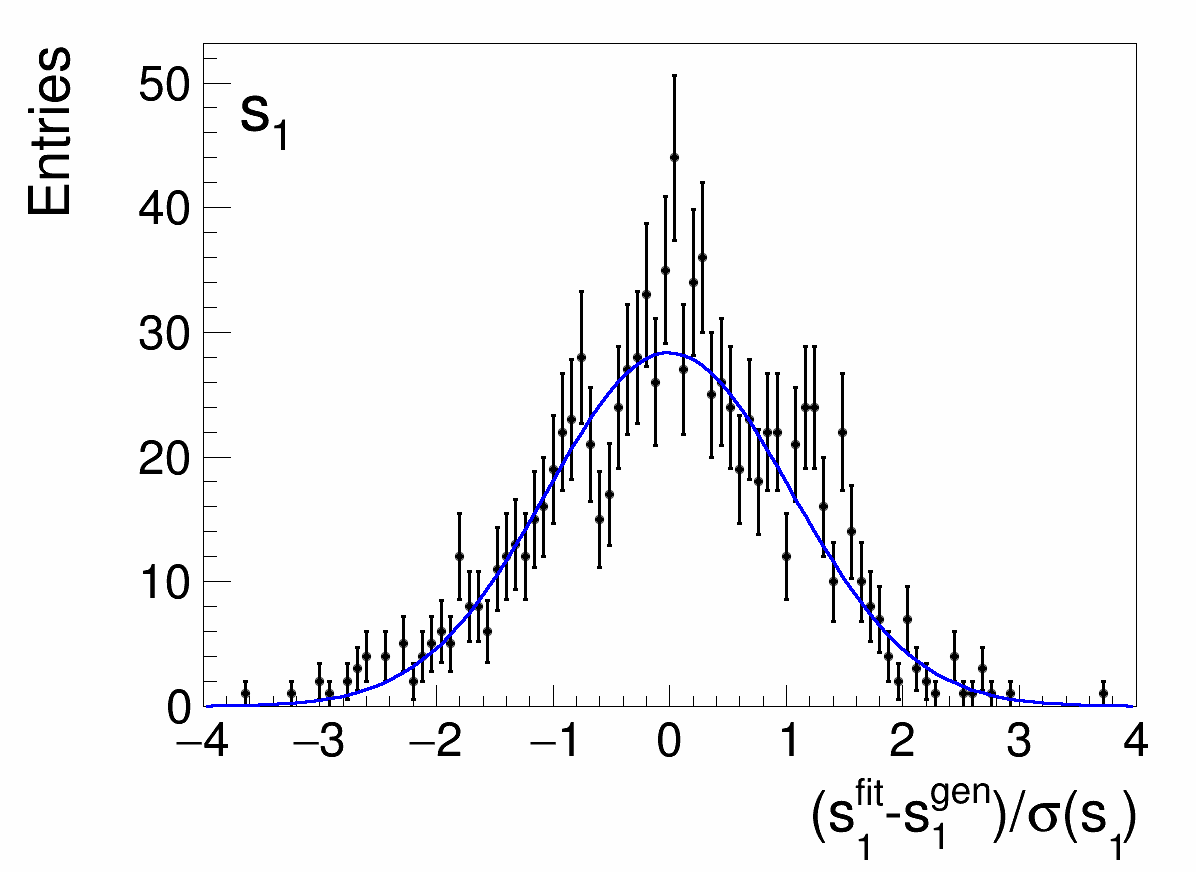

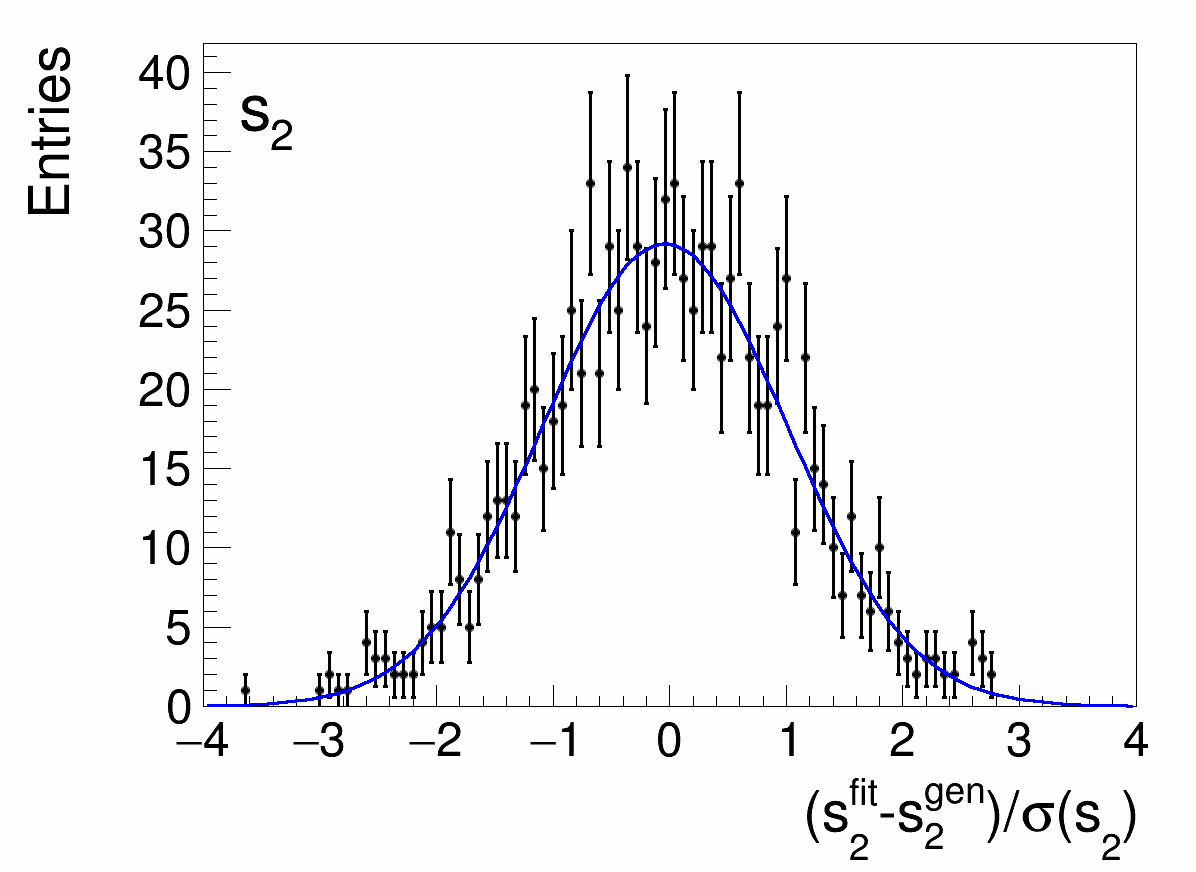

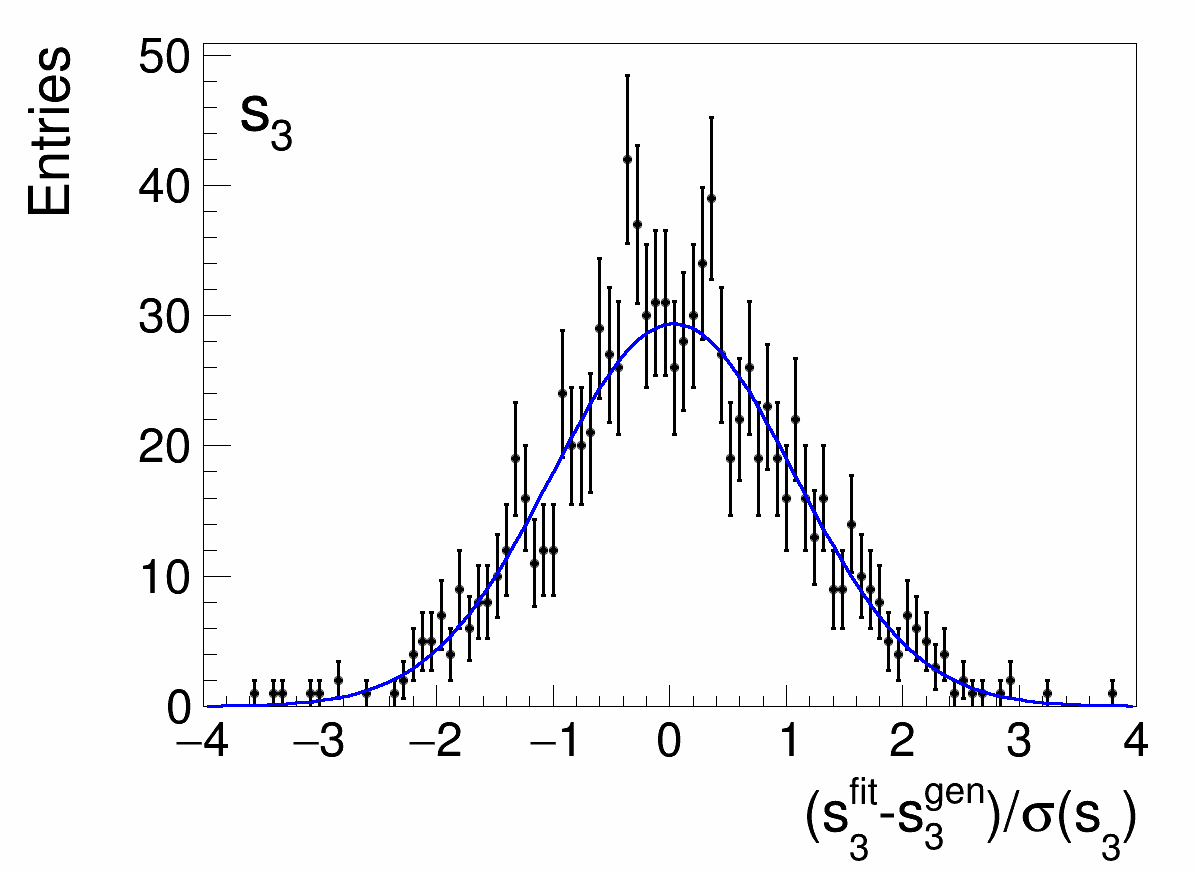

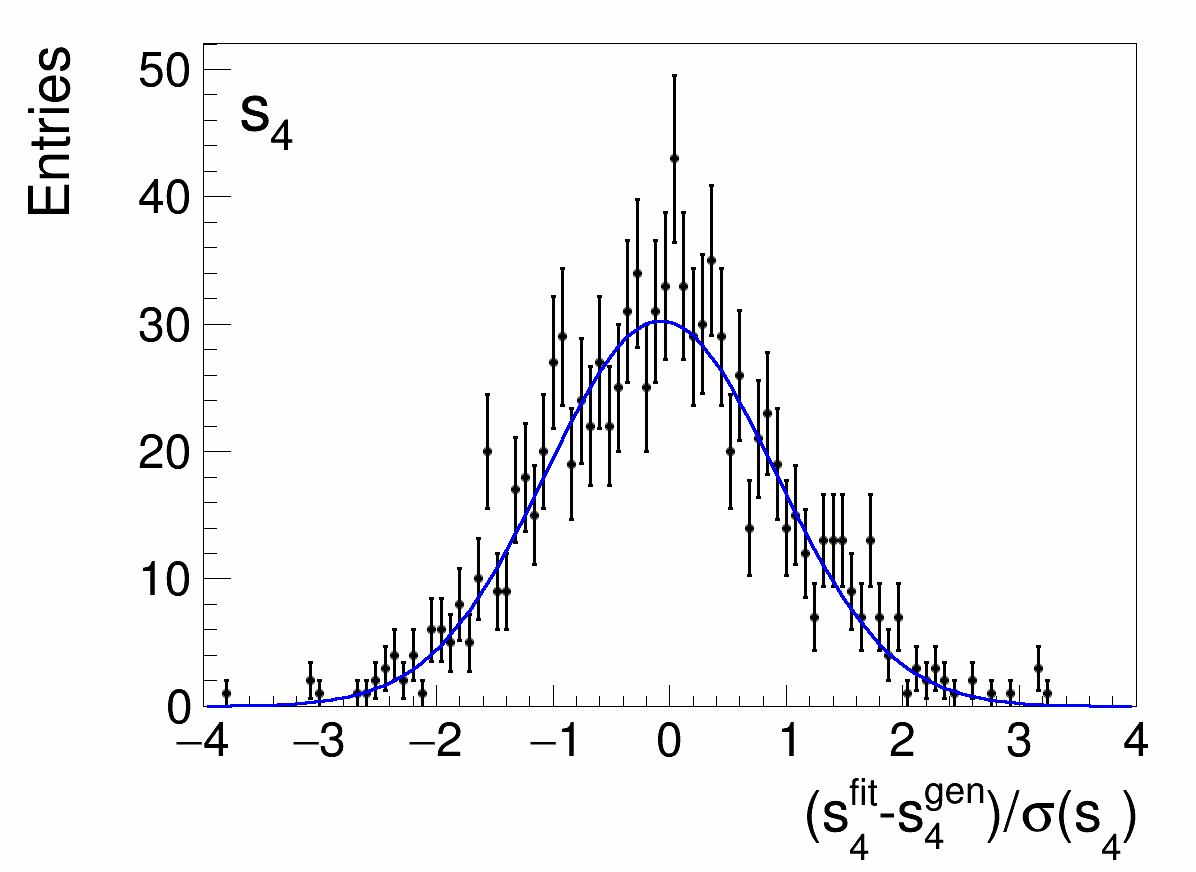

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       61.578
NDf                       =           71
Edm                       =  3.37837e-07
NCalls                    =           61
Constant                  =      29.1242   +/-   1.19947     
Mean                      =   -0.0997693   +/-   0.0349582   
Sigma                     =      1.03271   +/-   0.027449     	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       67.967
NDf                       =           68
Edm                       =   1.5192e-06
NCalls                    =           61
Constant                  =      31.2731   +/-   1.32312     
Mean                      =   -0.0291523   +/-   0.0327974   
Sigma                     =     0.950706   +/-   0.0263713    	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      62.3977
NDf                   

Info in <TCanvas::Print>: pdf file c1_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file c2_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file c3_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file c4_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file s1_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file s2_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file s3_ToyFits_pull.pdf has been created
Info in <TCanvas::Print>: pdf file s4_ToyFits_pull.pdf has been created


In [18]:
gStyle->SetOptFit(0011);
gStyle->SetOptStat(11);
gStyle->SetStatH(0.08);
for(const auto &Parameter : Parameters) {
    TCanvas *c1 = new TCanvas((Parameter + "_pull_c").c_str(), "", 1200, 900);
    Histograms_pull[Parameter].Draw("P E1");
    auto FitResult = Histograms_pull[Parameter].Fit("gaus", "SQ");
    //FitResult->Print("V");
    TF1 *FitFunction = Histograms_pull[Parameter].GetFunction("gaus");
    FitFunction->SetLineWidth(3);
    FitFunction->SetLineColor(kBlue);
    FitFunction->Draw("SAME");
    //std::cout << Parameter << " fit results:\n";
    //FitFunction->Print();
    //std::cout << "\n" << Parameter << ":\n";
    //FitResult->Print();
    if(Parameter[0] == 'c' || Parameter[0] == 's') {
        c1->SetBottomMargin(0.19);
        TLatex *Text = new TLatex;
        Text->SetTextFont(42);
        Text->SetTextSize(0.08);
        Text->SetTextColor(kBlack);
        Text->SetNDC(true);
        Text->SetText(0.2, 0.85, ParameterNames[Parameter].c_str());
        Text->Draw("SAME");
    }
    c1->Draw();
    c1->SaveAs((Parameter + "_ToyFits_pull.pdf").c_str());
    FitResult->Print();
    /*TCanvas *c2 = new TCanvas((Parameter + "_plus_err_c").c_str(), "", 1200, 900);
    Histograms_plus_err[Parameter].Draw();
    c2->Draw();
    TCanvas *c3 = new TCanvas((Parameter + "_minus_err_c").c_str(), "", 1200, 900);
    Histograms_minus_err[Parameter].Draw();
    c3->Draw();
    TCanvas *c4 = new TCanvas((Parameter + "_value_c").c_str(), "", 1200, 900);
    Histograms_value[Parameter].Draw();
    c4->Draw();
    TCanvas *c5 = new TCanvas((Parameter + "_err_c").c_str(), "", 1200, 900);
    Histograms_err[Parameter].Draw();
    c5->Draw();*/
    if(Parameter == "s4") {
        break;
    }
}